In [35]:
import numpy as np
import matplotlib.pyplot as plt

sentences = ["I love lyna so much ahihi",
            "Du bist gut genug",
            "Cam on anh anh Phung Thanh Do, na na na na",
            "I love Machine Learning",
            "I want to become a PhD so bad",
            "What doesn't kill you makes you stronger",
            "Why did you leave me?",
            "I am so handsome and happy!"]
vocab = sorted({w for s in sentences for w in s.lower().split()})
def to_vector(s):
  v = np.zeros(len(vocab))
  for w in s.lower().split():
    v[vocab.index(w)] += 1
  return v
X = np.array([to_vector(s) for s in sentences])
print(X.shape)


(8, 39)


# Bài 1 - Biểu diễn dữ liệu thành ma trận & độ tương đồng

In [36]:
def cosine_similarity(X, Y=None):
  if Y is None:
    Y = X
  Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
  Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
  return Xn @ Yn.T

#Top-k search dung cosine similarity:
def search(query, top_k=3):
  q = to_vector(query)
  q = q.reshape(1, -1) #(so_tu,) -> (1, so_tu)
  scores = cosine_similarity(q, X) #tinh tuong dong cosine giua q voi moi diem trong X
  scores = scores.ravel() #lam phang ve 1D

  top_k = min(top_k, len(sentences))
  top_indices = np.argsort(-scores)[:top_k] # cosine lon <=> cang similar (gan nhau)

  result = []
  for i in top_indices:
    result.append((i, scores[i], sentences[i]))
  return result

print(search("I love lyna so much na na na na"))


[(np.int64(2), np.float64(0.6982972487551757), 'Cam on anh anh Phung Thanh Do, na na na na'), (np.int64(0), np.float64(0.445435403187374), 'I love lyna so much ahihi'), (np.int64(3), np.float64(0.2182178902359924), 'I love Machine Learning')]


**Nhận xét**: Có thể thấy, kết quả của top-k search dùng cosine similarity ở trên là hợp lý về mặt toán học vì dữ liệu đang được biểu diễn bằng bag-of-words, trong đó mỗi vector lưu số lần xuất hiện của từng từ. Do đó, câu `"Cam on anh anh Phung Thanh Do, na na na na"` có độ tương đồng cao với câu truy vấn vì từ `"na"` xuất hiện nhiều lần ở cả hai câu, làm giá trị của tích vô hướng tăng lên. Tuy nhiên, kết quả này chưa hoàn toàn giống trực giác ngữ nghĩa của con người, vì mô hình không hiểu ý nghĩa câu, thứ tự từ hay ngữ cảnh, mà chỉ dựa trên sự trùng khớp từ vựng và tần suất xuất hiện. Điều này cho thấy hạn chế của bag-of-words: các từ lặp lại nhiều lần nhưng ít ý nghĩa vẫn có thể ảnh hưởng lớn đến độ tương đồng.


## Bonus: 1-NN Classifier dùng độ tương đồng cosine

Vì đây là classifier cho bài toán Supervised Learning, cụ thể là Classification, nên ta cần phải thêm target variable `y`.

In [37]:
# them target
y_train = np.array([
    "love",        # 0: I love lyna so much ahihi
    "german",      # 1: Du bist gut genug
    "thanks",      # 2: Cam on anh anh Phung Thanh Do, na na na na
    "ml",          # 3: I love Machine Learning
    "ambition",    # 4: I want to become a PhD so bad
    "motivation",  # 5: What doesn't kill you makes you stronger
    "sad",         # 6: Why did you leave me?
    "self"         # 7: I am so handsome and happy!
])

In [38]:
def predict_1nn_cosine_verbose(query, X_train, y_train, sentences):
    q = to_vector(query).reshape(1, -1)

    scores = cosine_similarity(q, X_train).ravel()

    nearest_idx = np.argmax(scores)

    return {
        "query": query,
        "predicted_label": y_train[nearest_idx],
        "nearest_index": nearest_idx,
        "nearest_sentence": sentences[nearest_idx],
        "cosine_similarity": scores[nearest_idx]
    }

result = predict_1nn_cosine_verbose(
    query="I love lyna and Machine Learning",
    X_train=X,
    y_train=y_train,
    sentences=sentences
)

print(result)

{'query': 'I love lyna and Machine Learning', 'predicted_label': np.str_('ml'), 'nearest_index': np.int64(3), 'nearest_sentence': 'I love Machine Learning', 'cosine_similarity': np.float64(0.8164965809277261)}


# Bài 2 - Biến đổi tuyến tính & SVD

Original X shape: (8, 39)
Centered Xc shape: (8, 39)
U shape: (8, 8)
S shape: (8,)
Vt shape: (8, 39)
Singular values: [4.80814585e+00 3.22045621e+00 2.41679604e+00 2.25108301e+00
 2.07034643e+00 2.03198114e+00 1.67685296e+00 5.51963823e-16]
2D coordinates shape: (8, 2)
[[-0.73804463  0.94739414]
 [-0.44183281 -0.17038269]
 [ 4.48898702  0.07420814]
 [-0.59730048  0.46432485]
 [-0.78938095  1.2746311 ]
 [-0.67490689 -2.37737968]
 [-0.54071901 -1.08731287]
 [-0.70680224  0.87451701]]


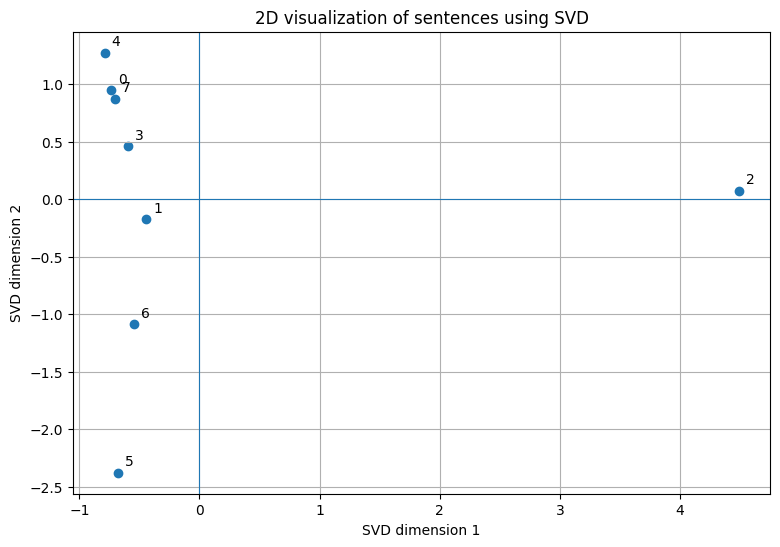

0: I love lyna so much ahihi
1: Du bist gut genug
2: Cam on anh anh Phung Thanh Do, na na na na
3: I love Machine Learning
4: I want to become a PhD so bad
5: What doesn't kill you makes you stronger
6: Why did you leave me?
7: I am so handsome and happy!


In [39]:
# center du lieu
Xc = X - X.mean(axis=0, keepdims=True)

print("Original X shape:", X.shape)
print("Centered Xc shape:", Xc.shape)

# SVD decomposition
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Singular values:", S)

# Lay toa do 2D cua moi cau
coords = U[:, :2] * S[:2]

print("2D coordinates shape:", coords.shape)
print(coords)

#Ve scatter plot
plt.figure(figsize=(9, 6))

plt.scatter(coords[:, 0], coords[:, 1])

for i, sentence in enumerate(sentences):
    plt.annotate(
        str(i),
        (coords[i, 0], coords[i, 1]),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left"
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("SVD dimension 1")
plt.ylabel("SVD dimension 2")
plt.title("2D visualization of sentences using SVD")
plt.grid(True)
plt.show()

for i, sentence in enumerate(sentences):
    print(f"{i}: {sentence}")

**Nhận xét**: Nhìn vào biểu đồ sau khi giảm chiều bằng SVD, các câu có một số từ chung hoặc có cấu trúc từ vựng gần nhau có xu hướng nằm gần nhau hơn, ví dụ các câu tiếng Anh ngắn có chứa các từ như `"I"`, `"love"` hoặc có dạng biểu diễn bag-of-words tương đối giống nhau. Tuy nhiên, sự phân cụm theo ngữ nghĩa hay chủ đề chưa được thể hiện rõ ràng vì dataset còn nhỏ và cách biểu diễn bag-of-words chỉ dựa trên tần suất xuất hiện của từ, nên mô hình không hiểu ý nghĩa thật sự, thứ tự từ hay ngữ cảnh của câu. Điểm số 2 nằm tách xa so với các điểm còn lại là do có các từ lặp lại nhiều lần như `"na"` và `"anh"` đã làm vector của câu này khác biệt hơn hẳn so với các câu còn lại. Về mặt ý tưởng, SVD trên dữ liệu đã được center có liên hệ gần gũi với PCA: nó tìm ra các *trục chính* của dữ liệu, tức những hướng mà dữ liệu biến thiên nhiều nhất. Trong biểu đồ này, trục SVD đầu tiên có thể được hiểu là hướng biến thiên mạnh nhất, chủ yếu tách câu số 2 ra khỏi phần còn lại, còn trục SVD thứ hai biểu diễn hướng biến thiên quan trọng tiếp theo.